# **Car Market Trends Analysis by Car Dekho Dataset**
Data Analysis by Syeda Tahoora Fatima

## About the Dataset
Car Dekho Dataset is a CSV type data source. It represents information about cars, likely for sale or historical records. It is having 301 rows and 9 columns. Here Exploratory Data Analysis will be conducted to find various reasons such as the Factors Affecting the Resale Value of Used Cars and Identifying the Characteristics That Help Cars Retain Their Market Value.


## Problem Statement
Analyzing the Factors Affecting the Resale Value of Used Cars and Identifying the Characteristics That Help Cars Retain Their Market Value.

In [42]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Importing Dataset
data=pd.read_csv("/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

In [44]:
# View the Dataset
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [45]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [46]:
# Display the number of rows and columns
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 301
Number of columns: 9


Insight

The dataset contains 301 used-car records and 9 variables, providing information about vehicle characteristics, pricing, usage, and seller details.

In [47]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [48]:
# Statistical Summary
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Average selling price ≈ 4.66 lakh
Average present price ≈ 7.63 lakh
Average kilometers driven ≈ 36,947 km
Manufacturing years range from 2003 to 2018
Maximum kilometers driven is 500,000 km
Most vehicles have 0 previous owners

Insight

The dataset contains cars with a wide range of prices and usage levels. The large difference between the minimum and maximum kilometers driven indicates substantial variation in vehicle usage, which makes mileage an important factor to investigate.

In [49]:
# Checking Missing values
# Count missing values in each column
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


Insight

There are no missing values in the dataset. Therefore, no imputation or missing-value treatment is required.

In [50]:
# Check Duplicate rows
# Count the number of duplicate rows
data.duplicated().sum()

np.int64(2)

In [51]:
# Display duplicate records
data[data.duplicated()]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [52]:
# Remove duplicate records
data = data.drop_duplicates()

# Reset the index after removing duplicates
data.reset_index(drop=True, inplace=True)

# Check the new shape
print("Dataset shape after removing duplicates:", data.shape)

Dataset shape after removing duplicates: (299, 9)


Insight

Two duplicate records were identified and removed to prevent duplicate observations from influencing the analysis.

In [53]:
# Display unique values for categorical columns

print("Fuel Types:")
print(data["Fuel_Type"].unique())

print("\nSeller Types:")
print(data["Seller_Type"].unique())

print("\nTransmission Types:")
print(data["Transmission"].unique())

print("\nOwner Types:")
print(data["Owner"].unique())

Fuel Types:
['Petrol' 'Diesel' 'CNG']

Seller Types:
['Dealer' 'Individual']

Transmission Types:
['Manual' 'Automatic']

Owner Types:
[0 1 3]


In [54]:
# Number of Numerical Column
num_numeric_cols = data.select_dtypes(include=['int64','float64'])
print("No.of Numerical Columns in the Dataset:",len(num_numeric_cols.columns))

No.of Numerical Columns in the Dataset: 5


In [55]:
# Number of Categorical Column
num_categorical_cols = data.select_dtypes(include=['object'])
print("No.of Categorical Columns in the Dataset:",len(num_categorical_cols.columns))

No.of Categorical Columns in the Dataset: 4


### Feature Engineering

In [56]:
# Creating Car Age

# Calculate the age of each car
data["Car_Age"] = 2018 - data["Year"]

# Display the result
data[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


In [57]:
# Calculate Depreciation(Reduction)

# Calculate the absolute depreciation amount
data["Depreciation"] = data["Present_Price"] - data["Selling_Price"]

# Display the result
data[["Present_Price", "Selling_Price", "Depreciation"]].head()

,Present_Price,Selling_Price,Depreciation
0,5.59,3.35,2.24
1,9.54,4.75,4.79
2,9.85,7.25,2.60
3,4.15,2.85,1.30
4,6.87,4.60,2.27


In [58]:
# Calculate Resale Value Percentage

# Calculate the percentage of the present price retained as selling price
data["Resale_Value_Percentage"] = (
    data["Selling_Price"] / data["Present_Price"]
) * 100

# Display the first few values
data[[
    "Present_Price",
    "Selling_Price",
    "Resale_Value_Percentage"
]].head()

,Present_Price,Selling_Price,Resale_Value_Percentage
0,5.59,3.35,59.928444
1,9.54,4.75,49.790356
2,9.85,7.25,73.604061
3,4.15,2.85,68.674699
4,6.87,4.60,66.957787


In [59]:
# Extract Car Brand

# Extract the first word from the car name as an approximate brand
data["Brand"] = data["Car_Name"].str.split().str[0]

# Display brand and car name
data[["Car_Name", "Brand"]].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [60]:
# Checking new dataset
# Display all columns after feature engineering
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation,Resale_Value_Percentage,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,2.24,59.928444,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,4.79,49.790356,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,2.60,73.604061,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,1.30,68.674699,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,2.27,66.957787,swift


In [61]:
data.shape

(299, 13)

### Univariate Analysis

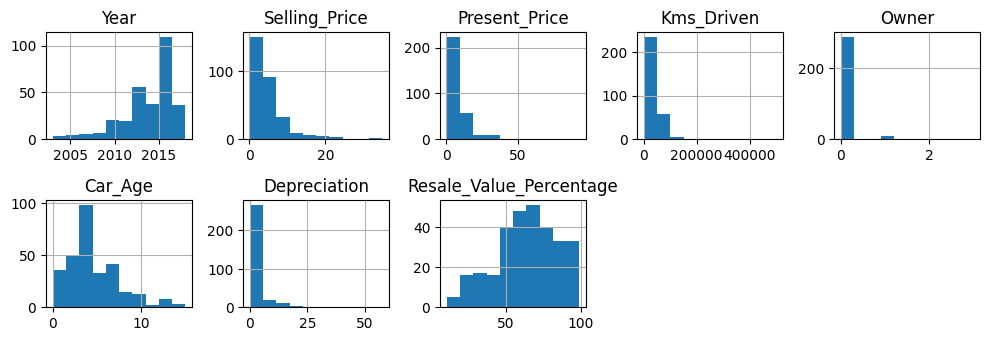

In [62]:
# Histogram for all numerical features
data.hist(bins=10,layout=(6,5),figsize=(10,10))
plt.tight_layout()
plt.show()

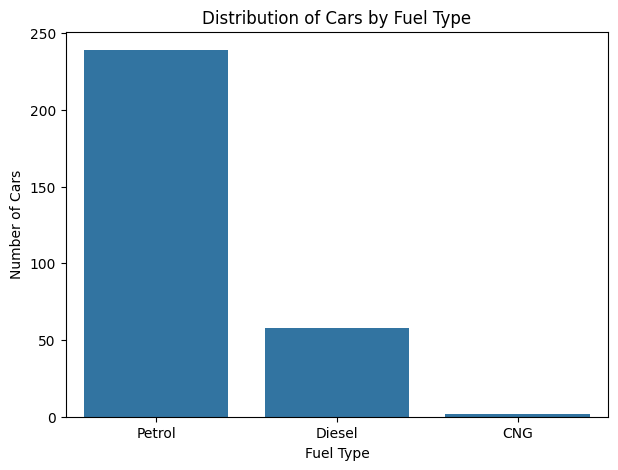

In [67]:
# Fuel Type Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Fuel_Type"
)

plt.title("Distribution of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

Insight

Petrol vehicles are expected to form the largest share of the dataset, followed by diesel and CNG vehicles. This distribution should be considered when comparing resale values because groups with very few observations may produce less reliable averages.

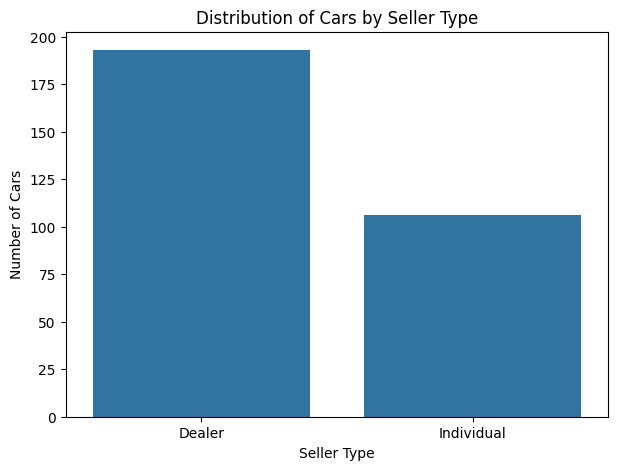

In [69]:
# Seller Type
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Seller_Type"
)

plt.title("Distribution of Cars by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Number of Cars")

plt.show()

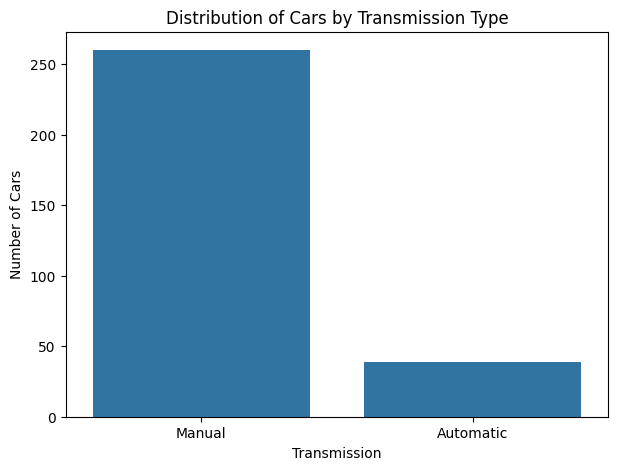

In [71]:
# Tranmission type
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Transmission"
)

plt.title("Distribution of Cars by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.show()

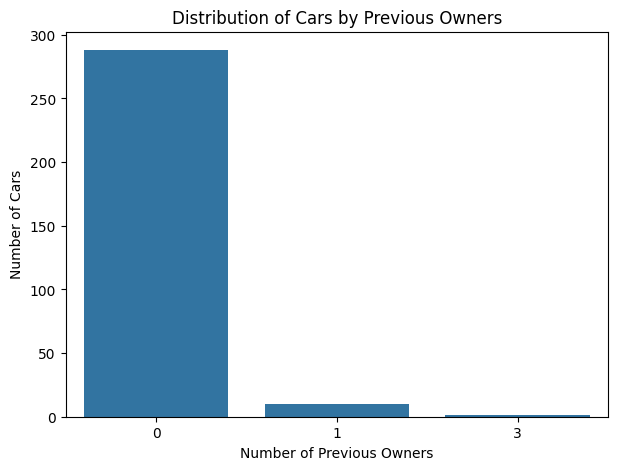

In [72]:
# Previous Owners
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Owner"
)

plt.title("Distribution of Cars by Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Number of Cars")

plt.show()

Insight

The majority of cars have no previous owners recorded, while cars with one or more previous owners are comparatively fewer. Therefore, owner-based conclusions should be interpreted carefully because of the uneven group sizes.

### Bivariate Analysis

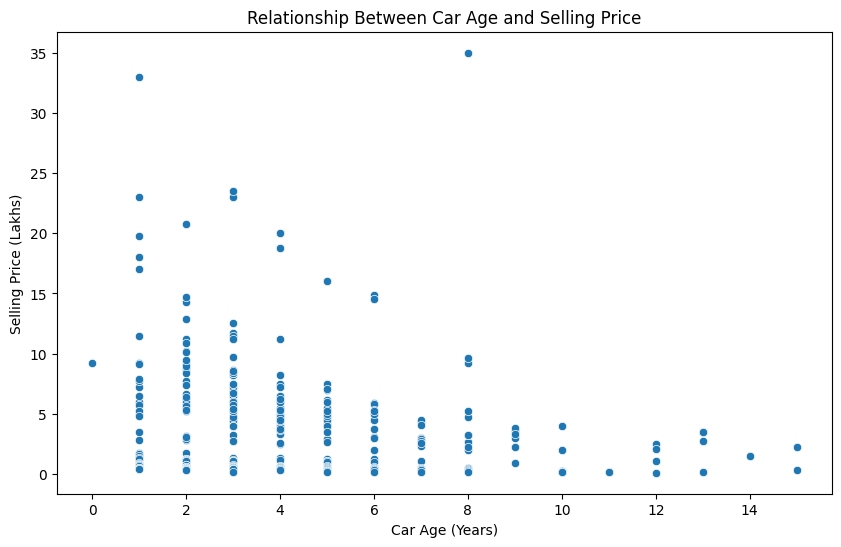

In [65]:
#Car Age vs Selling Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Relationship Between Car Age and Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

Insight

Older cars generally have lower selling prices, indicating that vehicle age is an important factor associated with resale price

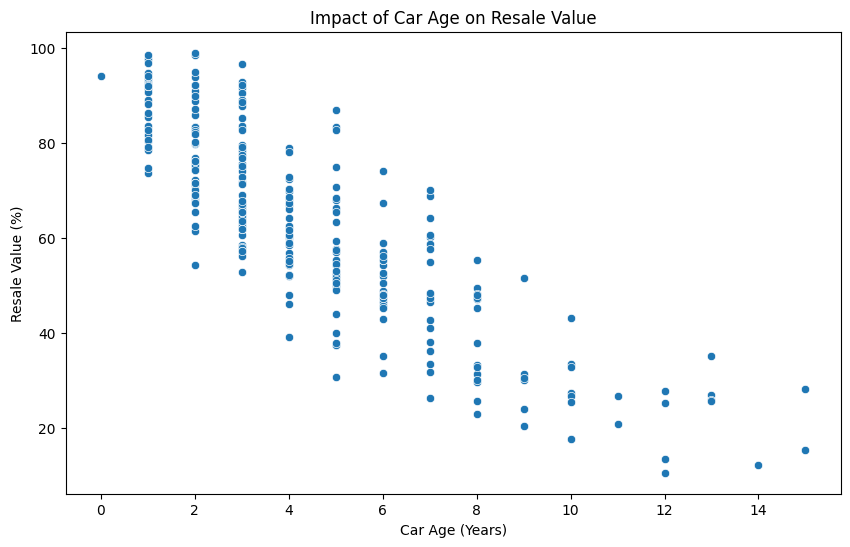

In [74]:
# Car Age vs Resale value
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Car_Age",
    y="Resale_Value_Percentage"
)

plt.title("Impact of Car Age on Resale Value")
plt.xlabel("Car Age (Years)")
plt.ylabel("Resale Value (%)")

plt.show()

Insight

A downward relationship would indicate that older cars generally retain a smaller percentage of their original/current value, suggesting that depreciation increases with vehicle age.

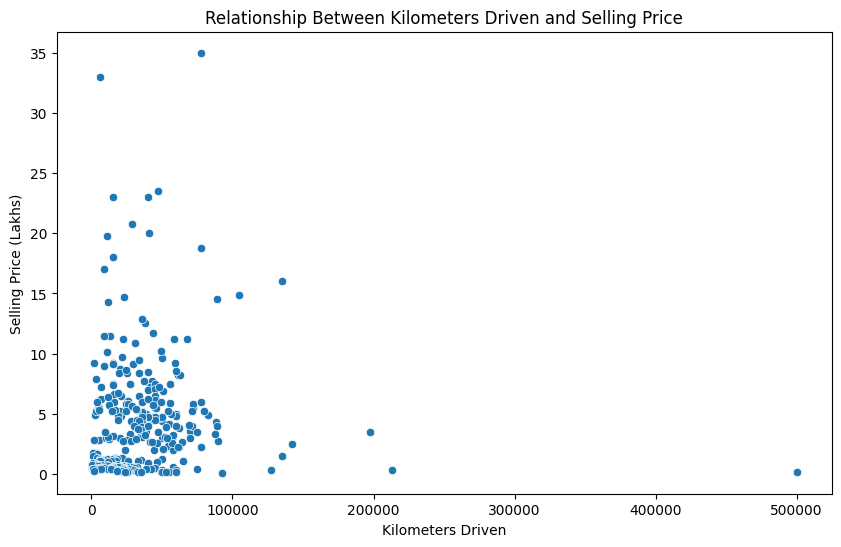

In [76]:
# Kms Driven vs Selling Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Relationship Between Kilometers Driven and Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

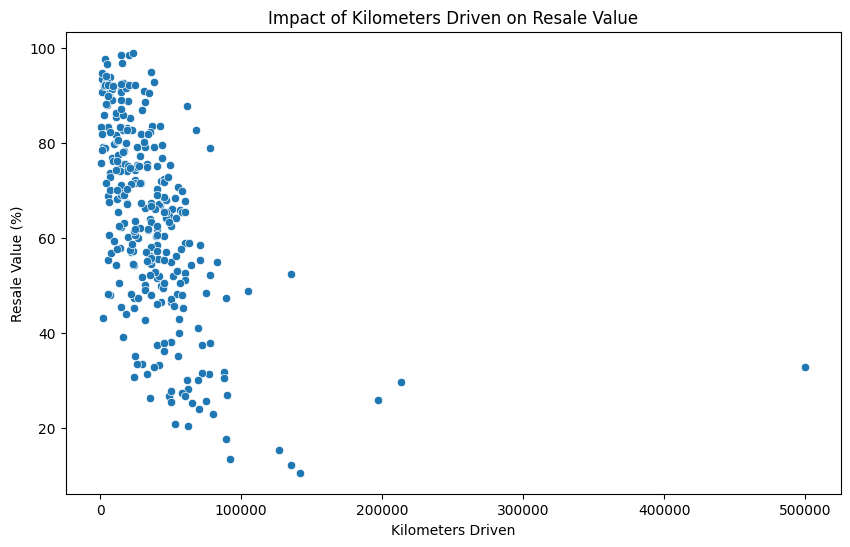

In [78]:
# Kms Driven vs Resale Value
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Kms_Driven",
    y="Resale_Value_Percentage"
)

plt.title("Impact of Kilometers Driven on Resale Value")
plt.xlabel("Kilometers Driven")
plt.ylabel("Resale Value (%)")

plt.show()

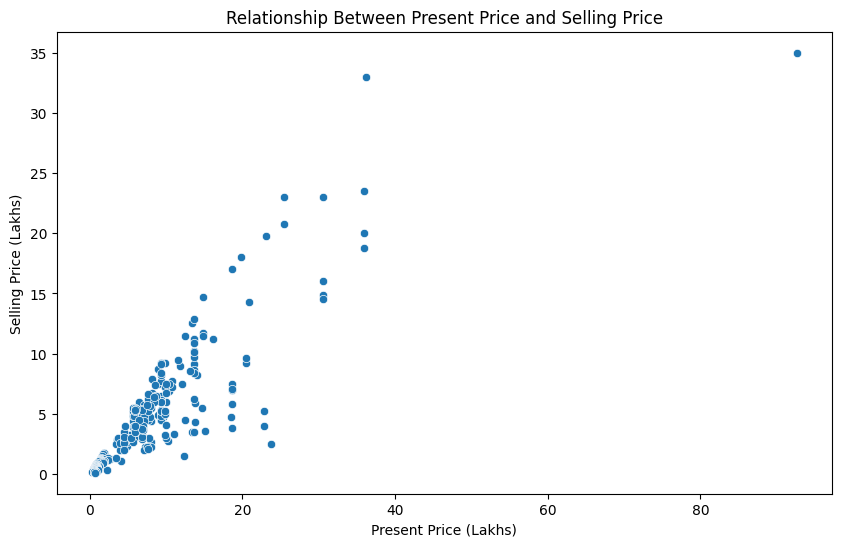

In [79]:
# Present Price vs Selling Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Relationship Between Present Price and Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

### Categorical Variables vs Resale Value

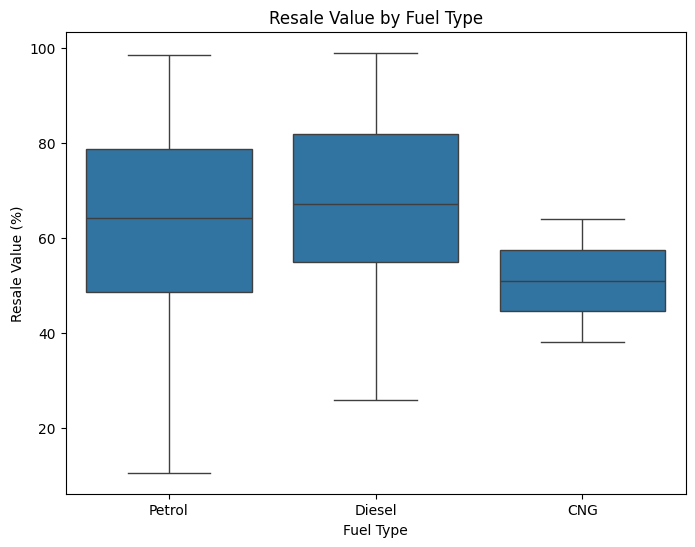

In [80]:
# Fuel Type vs Resale Value
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Fuel_Type",
    y="Resale_Value_Percentage"
)

plt.title("Resale Value by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Resale Value (%)")

plt.show()

Insight

Compare the median resale percentage across fuel types. The fuel category with a higher median indicates better value retention within this dataset. However, group sizes should also be considered before drawing strong conclusions.

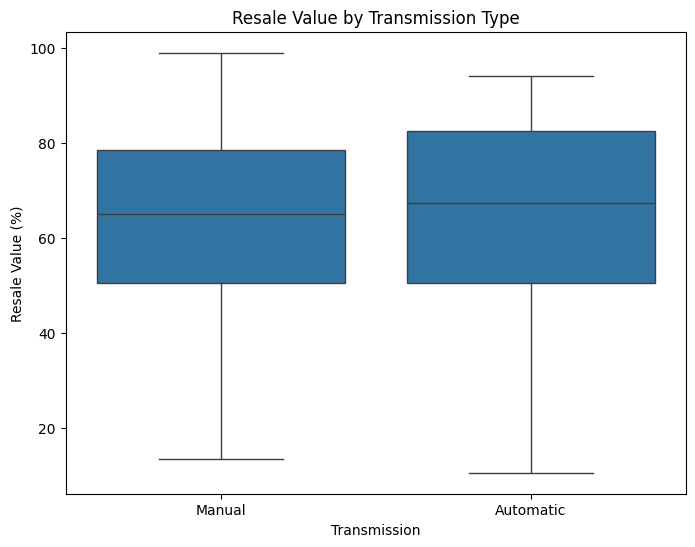

In [81]:
# Transmission vs Resale Value
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Transmission",
    y="Resale_Value_Percentage"
)

plt.title("Resale Value by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Resale Value (%)")

plt.show()

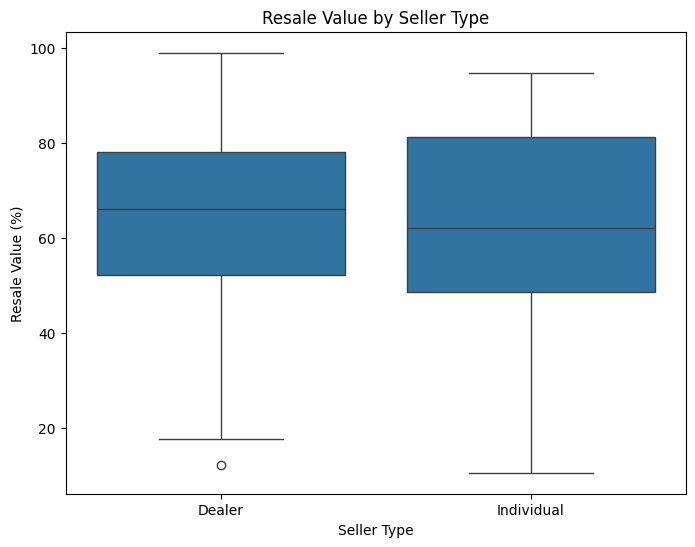

In [82]:
# Seller Type vs Resale Value
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Seller_Type",
    y="Resale_Value_Percentage"
)

plt.title("Resale Value by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Resale Value (%)")

plt.show()

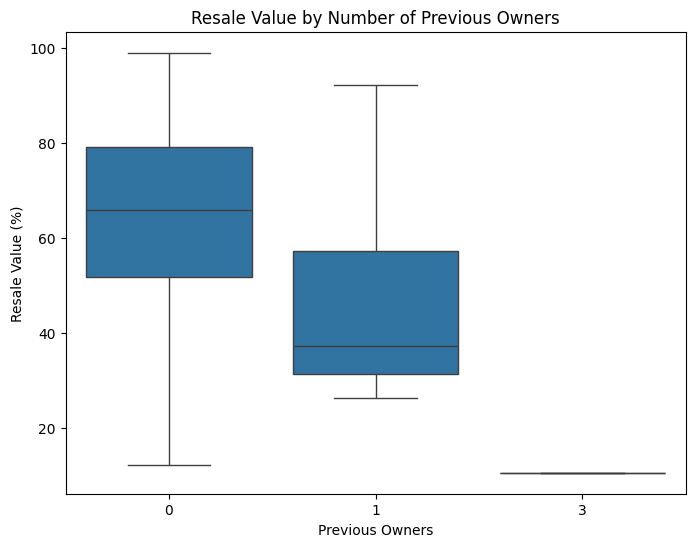

In [83]:
# Previous Owners vs Resale Value
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Owner",
    y="Resale_Value_Percentage"
)

plt.title("Resale Value by Number of Previous Owners")
plt.xlabel("Previous Owners")
plt.ylabel("Resale Value (%)")

plt.show()

### Brand-Level Analysis

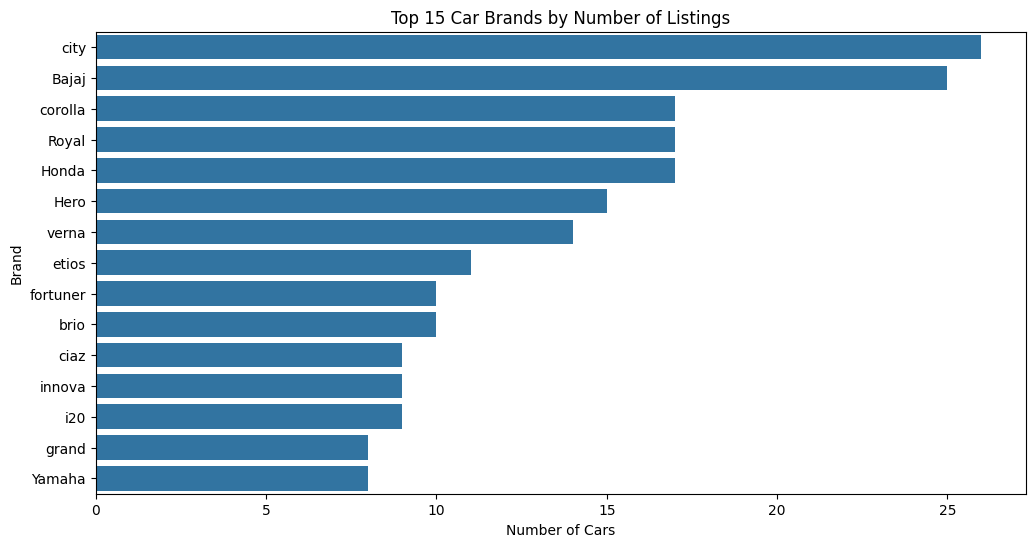

In [84]:
# Count the number of cars for each brand
brand_counts = data["Brand"].value_counts().head(15)

# Plot the top 15 brands
plt.figure(figsize=(12, 6))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title("Top 15 Car Brands by Number of Listings")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")

plt.show()

Insight

The dataset is not evenly distributed across brands. Some brands have significantly more observations than others, so brand-level comparisons should account for sample size.

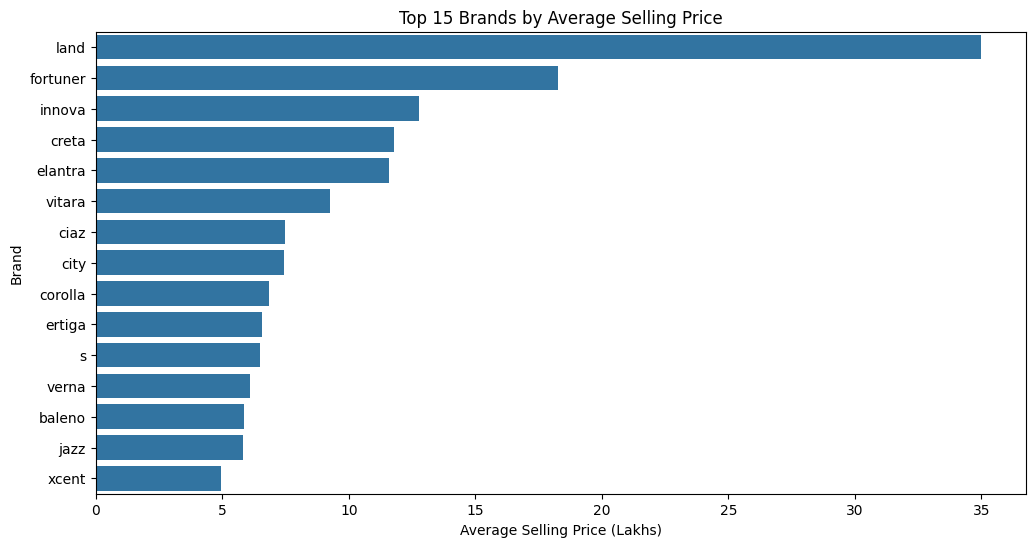

In [85]:
# Average Selling Price by Brand

# Calculate average selling price for each brand
brand_price = (
    data.groupby("Brand")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=brand_price.values,
    y=brand_price.index
)

plt.title("Top 15 Brands by Average Selling Price")
plt.xlabel("Average Selling Price (Lakhs)")
plt.ylabel("Brand")

plt.show()

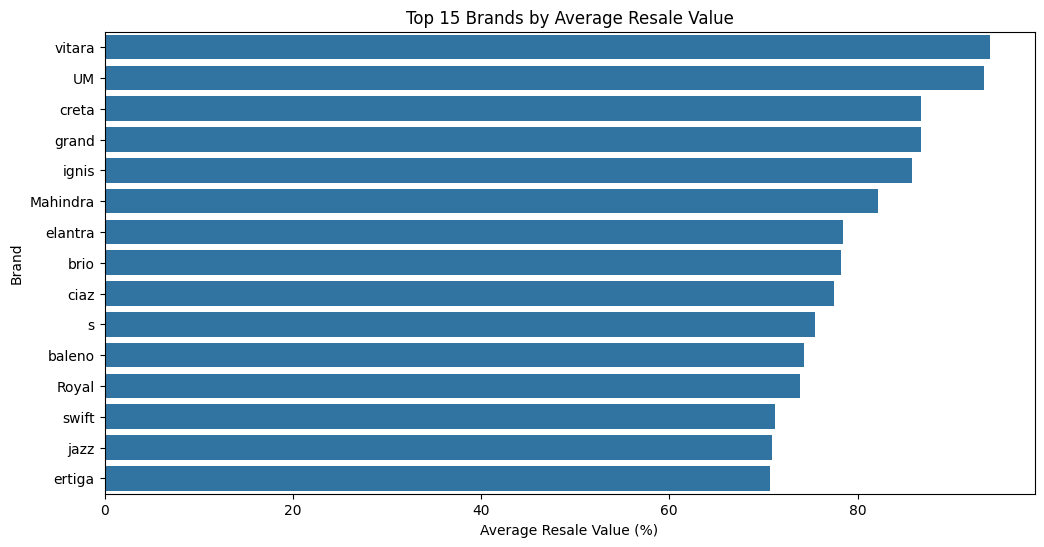

In [86]:
#Average Resale Value by Brand

# Calculate average resale value percentage by brand
brand_resale = (
    data.groupby("Brand")["Resale_Value_Percentage"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=brand_resale.values,
    y=brand_resale.index
)

plt.title("Top 15 Brands by Average Resale Value")
plt.xlabel("Average Resale Value (%)")
plt.ylabel("Brand")

plt.show()

In [87]:
# Consider only brands with at least 5 cars
brand_analysis = (
    data.groupby("Brand")
    .agg(
        Car_Count=("Car_Name", "count"),
        Avg_Selling_Price=("Selling_Price", "mean"),
        Avg_Resale_Value=("Resale_Value_Percentage", "mean")
    )
)

# Filter brands with at least 5 observations
brand_analysis_filtered = (
    brand_analysis[brand_analysis["Car_Count"] >= 5]
    .sort_values("Avg_Resale_Value", ascending=False)
)

brand_analysis_filtered.head(10)

,Car_Count,Avg_Selling_Price,Avg_Resale_Value
Brand,,,
grand,8,4.943750,86.732456
brio,10,4.745000,78.253755
ciaz,9,7.472222,77.512284
Royal,17,1.144706,73.859941
swift,5,4.540000,71.262907
jazz,7,5.828571,70.946255
ertiga,5,6.580000,70.732825
alto,6,2.616667,69.466263
Yamaha,8,0.582500,69.350963


In [88]:
# Correlation Analysis
# Select numerical variables for correlation analysis
numeric_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age",
    "Depreciation",
    "Resale_Value_Percentage"
]

# Calculate correlation matrix
correlation_matrix = data[numeric_columns].corr()

# Display correlation matrix
correlation_matrix

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Depreciation,Resale_Value_Percentage
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639,-1.000000,-0.336349,0.848636
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880,-0.234369,0.521860,0.230115
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947,0.053563,0.868186,-0.109518
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367,0.525714,0.334104,-0.506720
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000,0.181639,0.108164,-0.222203
Car_Age,-1.000000,-0.234369,0.053563,0.525714,0.181639,1.000000,0.336349,-0.848636
Depreciation,-0.336349,0.521860,0.868186,0.334104,0.108164,0.336349,1.000000,-0.431072
Resale_Value_Percentage,0.848636,0.230115,-0.109518,-0.506720,-0.222203,-0.848636,-0.431072,1.000000


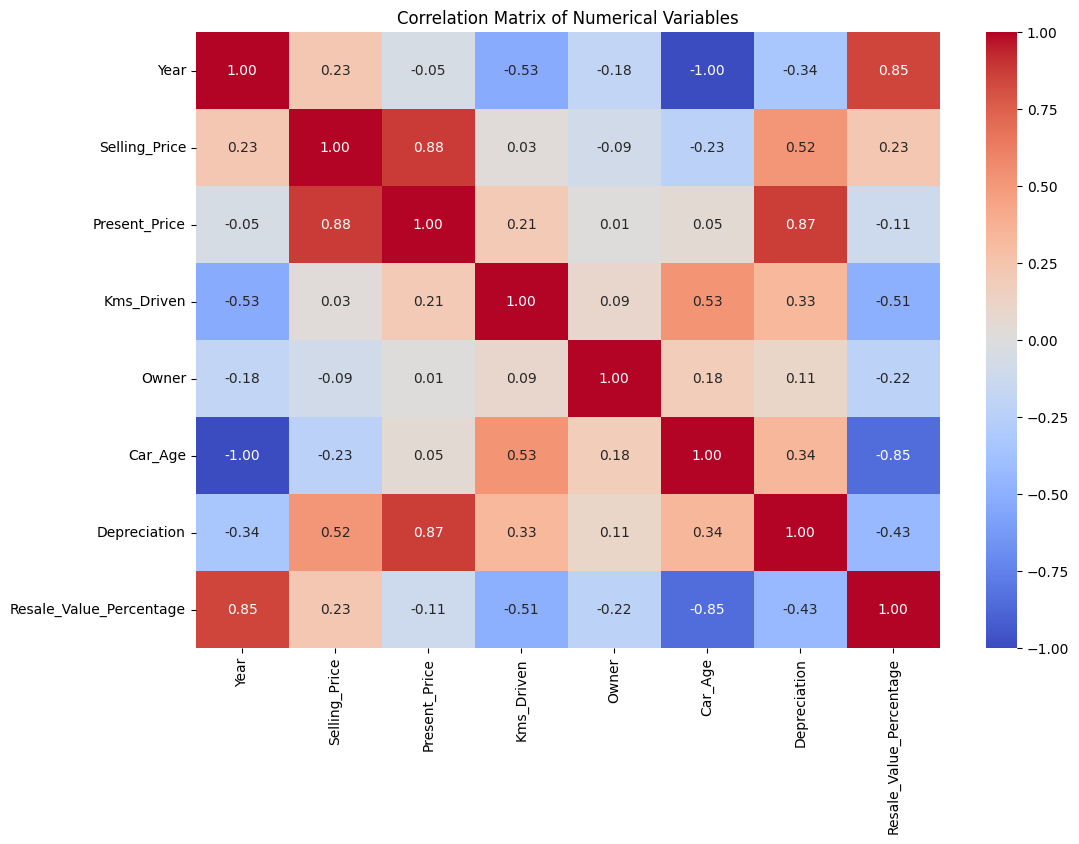

In [89]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

### Outlier Analysis

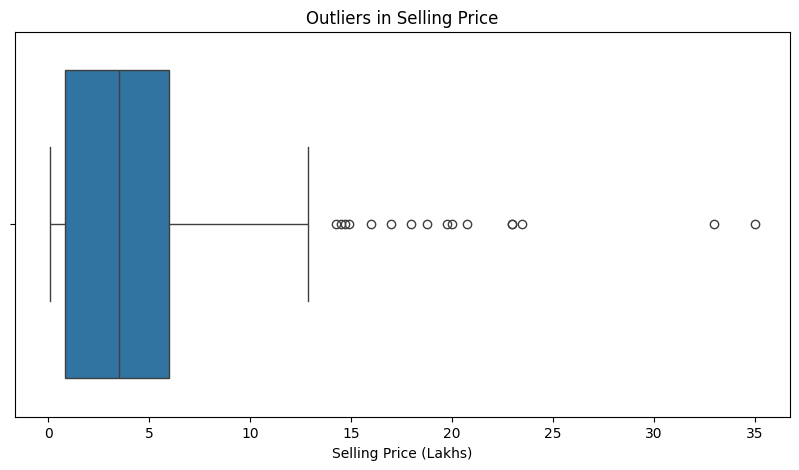

In [90]:
# Selling Price
plt.figure(figsize=(10, 5))

sns.boxplot(x=data["Selling_Price"])

plt.title("Outliers in Selling Price")
plt.xlabel("Selling Price (Lakhs)")

plt.show()

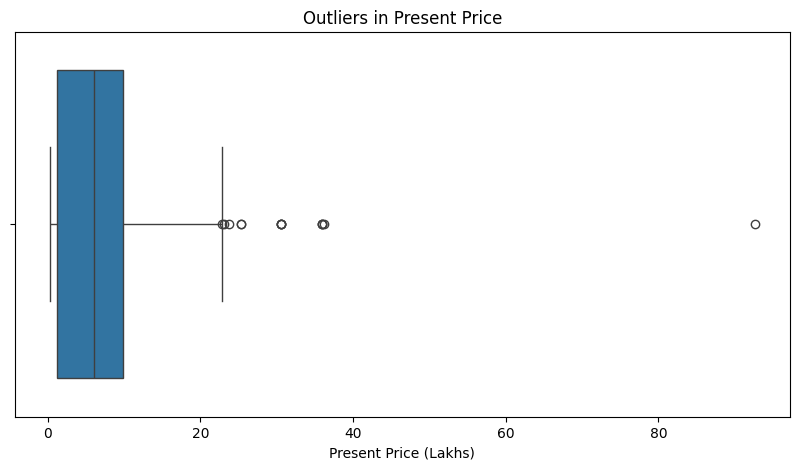

In [91]:
# Present Price
plt.figure(figsize=(10, 5))

sns.boxplot(x=data["Present_Price"])

plt.title("Outliers in Present Price")
plt.xlabel("Present Price (Lakhs)")

plt.show()

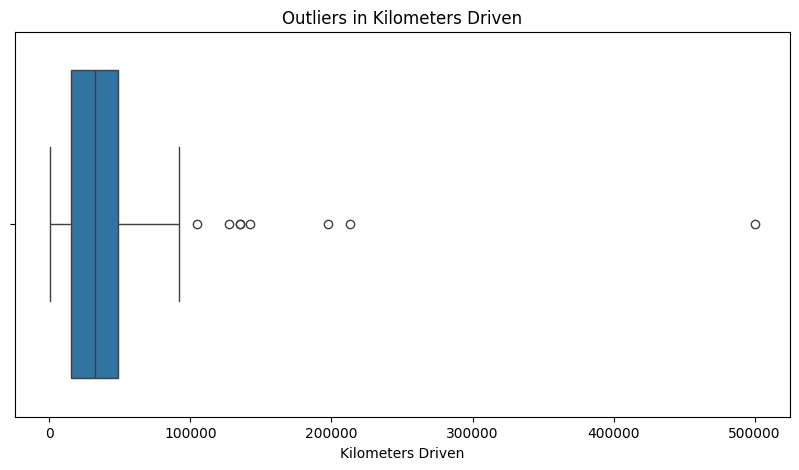

In [92]:
# Kilometers Driven
plt.figure(figsize=(10, 5))

sns.boxplot(x=data["Kms_Driven"])

plt.title("Outliers in Kilometers Driven")
plt.xlabel("Kilometers Driven")

plt.show()

In [94]:
# Compare average resale value across categorical variables

print("Average Resale Value by Fuel Type:")
print(
    data.groupby("Fuel_Type")["Resale_Value_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Resale Value by Seller Type:")
print(
    data.groupby("Seller_Type")["Resale_Value_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Resale Value by Transmission:")
print(
    data.groupby("Transmission")["Resale_Value_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Resale Value by Owner:")
print(
    data.groupby("Owner")["Resale_Value_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

Average Resale Value by Fuel Type:
Fuel_Type
Diesel    67.774273
Petrol    62.414885
CNG       50.982191
Name: Resale_Value_Percentage, dtype: float64

Average Resale Value by Seller Type:
Seller_Type
Dealer        63.905712
Individual    62.417239
Name: Resale_Value_Percentage, dtype: float64

Average Resale Value by Transmission:
Transmission
Automatic    63.642459
Manual       63.338361
Name: Resale_Value_Percentage, dtype: float64

Average Resale Value by Owner:
Owner
0    64.171207
1    45.818698
3    10.535188
Name: Resale_Value_Percentage, dtype: float64


In [95]:
#  a summary of important numerical variables

summary = data[
    [
        "Selling_Price",
        "Present_Price",
        "Kms_Driven",
        "Car_Age",
        "Depreciation",
        "Resale_Value_Percentage"
    ]
].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Selling_Price,299.0,4.589632,4.984240,0.100000,0.850000,3.510000,6.0000,35.000000
Present_Price,299.0,7.541037,8.567887,0.320000,1.200000,6.100000,9.8400,92.600000
Kms_Driven,299.0,36916.752508,39015.170352,500.000000,15000.000000,32000.000000,48883.5000,500000.000000
Car_Age,299.0,4.384615,2.896868,0.000000,2.000000,4.000000,6.0000,15.000000
Depreciation,299.0,2.951405,4.837450,0.030000,0.390000,1.610000,3.3500,57.600000
Resale_Value_Percentage,299.0,63.378026,20.287451,10.535188,50.505051,65.425532,79.0624,98.925453


## Conclusion

This exploratory data analysis examined the factors influencing the
resale value of used cars in the CarDekho dataset.

The analysis considered vehicle age, present price, kilometers driven,
fuel type, seller type, transmission, previous ownership, and brand.

The results indicate that vehicle age, mileage, and present market price
are important factors associated with used-car selling prices and value
retention. Differences were also observed across fuel types, transmission
types, seller types, and brands.

Overall, the analysis suggests that vehicles with lower age and mileage
and stronger market value tend to retain a greater proportion of their
value in the used-car market.

The findings can help buyers understand which characteristics are
associated with better value retention and can help sellers understand
the factors that influence the resale price of their vehicles.

                    USED CAR
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
       Car Age     Kms Driven    Car Features
          │            │            │
          └────────────┼────────────┘
                       ↓
                VALUE RETENTION
                       ↓
              Resale Value (%)
                       ↓
             Market Insights